In [1]:
# Exploratory Data Analysis on Titanic Dataset

## Objective
#The objective of this analysis is to explore the Titanic dataset, understand its structure, identify patterns and trends, detect missing values and anomalies, and derive meaningful insights regarding passenger survival.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns
pd.set_option('display.max_columns', None)

In [3]:
#Load Dataset
df = pd.read_csv("Titanic.csv")

In [4]:
df.head()

,pclass,survived,name,gender,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


## Questions Before Analysis

1. What is the overall survival rate?
2. Did gender affect survival?
3. Did passenger class affect survival?
4. Does age influence survival?
5. Does fare influence survival?
6. Are there missing values in the dataset?
7. Which embarkation point had the highest survival rate?
8. Are there any anomalies or outliers in fare and age?

In [5]:
df.shape
df.columns
df.dtypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pclass     1309 non-null   int64  
 1   survived   1309 non-null   int64  
 2   name       1309 non-null   object 
 3   gender     1309 non-null   object 
 4   age        1046 non-null   float64
 5   sibsp      1309 non-null   int64  
 6   parch      1309 non-null   int64  
 7   ticket     1309 non-null   object 
 8   fare       1308 non-null   float64
 9   cabin      295 non-null    object 
 10  embarked   1307 non-null   object 
 11  boat       486 non-null    object 
 12  body       121 non-null    float64
 13  home.dest  745 non-null    object 
dtypes: float64(3), int64(4), object(7)
memory usage: 143.3+ KB


### Observation

The dataset contains 1309 passenger records with a mix of numerical and categorical features.
Several columns contain missing values which need further investigation.

In [6]:
#Statistical Summary
df.describe()

,pclass,survived,age,sibsp,parch,fare,body
count,1309.000000,1309.000000,1046.000000,1309.000000,1309.000000,1308.000000,121.000000
mean,2.294882,0.381971,29.881135,0.498854,0.385027,33.295479,160.809917
std,0.837836,0.486055,14.413500,1.041658,0.865560,51.758668,97.696922
min,1.000000,0.000000,0.166700,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,21.000000,0.000000,0.000000,7.895800,72.000000
50%,3.000000,0.000000,28.000000,0.000000,0.000000,14.454200,155.000000
75%,3.000000,1.000000,39.000000,1.000000,0.000000,31.275000,256.000000
max,3.000000,1.000000,80.000000,8.000000,9.000000,512.329200,328.000000


## Statistical Summary Observations

1. The dataset contains 1309 passenger records.

2. The average age of passengers is approximately 29.88 years.

3. The youngest passenger was approximately 0.17 years old, while the oldest passenger was 80 years old.

4. The average fare paid by passengers was 33.30.

5. The fare values range from 0 to 512.33, indicating the presence of potential outliers.

6. Most passengers belonged to third class, as the median passenger class is 3.

7. The average number of siblings/spouses aboard was 0.50, while the average number of parents/children aboard was 0.39.

### Observation

The average passenger age is around 30 years.
The fare column shows large variation, indicating possible outliers.

In [20]:
#Missing Values Analysis
df.isnull().sum()


pclass          0
survived        0
name            0
gender          0
age           263
sibsp           0
parch           0
ticket          0
fare            1
cabin        1014
embarked        2
boat          823
body         1188
home.dest     564
dtype: int64

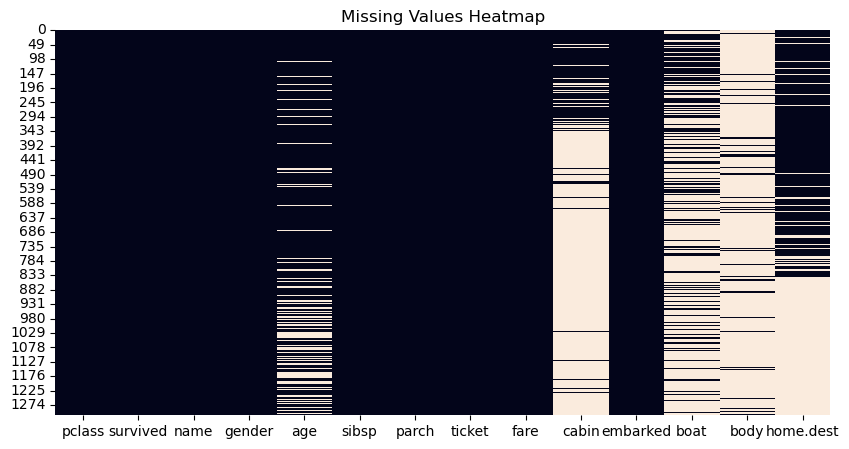

In [22]:
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

## Missing Values Analysis

The dataset contains missing values in several columns.

- Age has 263 missing values.
- Fare has only 1 missing value.
- Embarked has 2 missing values.
- Cabin contains 1014 missing values.
- Boat contains 823 missing values.
- Body contains 1188 missing values.
- Home destination contains 564 missing values.

Cabin and Body have a very large number of missing values and may not be reliable for detailed analysis.

Age contains a moderate number of missing values and may require imputation during data preprocessing.

### Observation

Several columns contain missing values.
Cabin and Body have a significant amount of missing data and may not be suitable for detailed analysis.

In [9]:
#Duplicate Records
df.duplicated().sum()


0

In [10]:
survival_rate = df['survived'].mean()*100
print(f"Survival Rate: {survival_rate:.2f}%")

Survival Rate: 38.20%


### Observation

The overall survival rate provides an overview of passenger outcomes aboard the Titanic.

In [11]:
#Gender vs Survival
pd.crosstab(df['gender'], df['survived'])

survived,0,1
gender,,
female,127,339
male,682,161


In [12]:
pd.crosstab(
    df['gender'],
    df['survived'],
    normalize='index'
)*100

survived,0,1
gender,,
female,27.253219,72.746781
male,80.901542,19.098458


### Hypothesis

Female passengers had a higher survival rate than male passengers.

### Conclusion

The hypothesis is supported if females show a significantly higher survival percentage.

In [13]:
#Passenger Class vs Survival
pd.crosstab(df['pclass'], df['survived'])

survived,0,1
pclass,,
1,123,200
2,158,119
3,528,181


In [14]:
pd.crosstab(
    df['pclass'],
    df['survived'],
    normalize='index'
)*100

survived,0,1
pclass,,
1,38.080495,61.919505
2,57.039711,42.960289
3,74.471086,25.528914


### Hypothesis

Passengers in higher classes had better chances of survival.

In [15]:
#Age Analysis
df['age'].describe()

count    1046.000000
mean       29.881135
std        14.413500
min         0.166700
25%        21.000000
50%        28.000000
75%        39.000000
max        80.000000
Name: age, dtype: float64

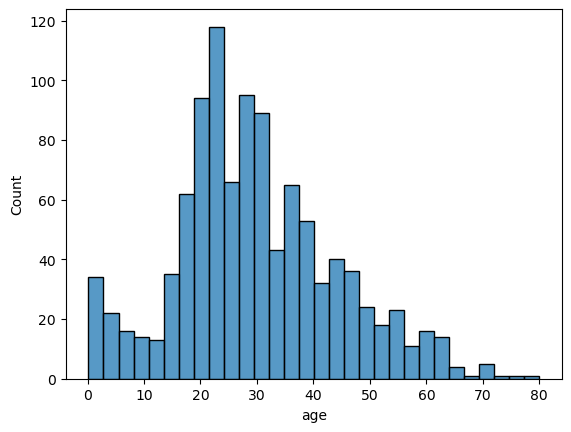

In [16]:
sns.histplot(df['age'], bins=30)
plt.show()

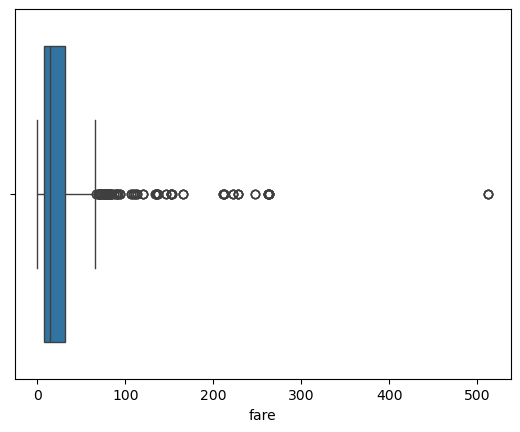

In [17]:
#Fare Analysis
df['fare'].describe()
sns.boxplot(x=df['fare'])
plt.show()

### Observation

The fare column contains several high-value outliers.
These passengers likely belonged to higher passenger classes.

In [18]:
#Correlation Analysis
numeric_df = df.select_dtypes(include=['number'])

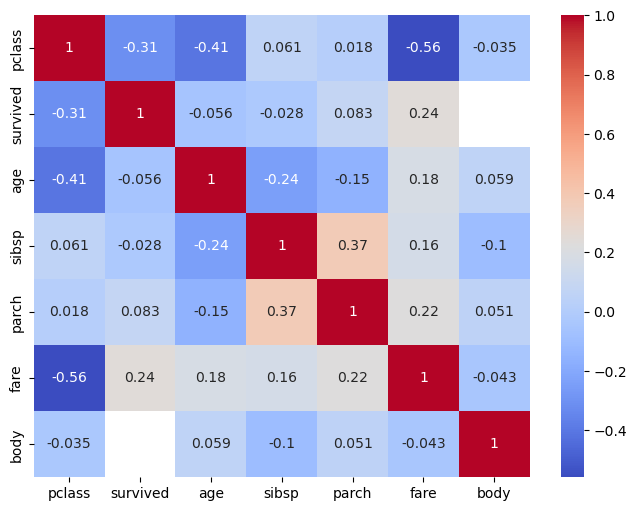

In [19]:
plt.figure(figsize=(8,6))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)
plt.show()

# Key Findings

1. Female passengers had a significantly higher survival rate.
2. First-class passengers were more likely to survive.
3. The dataset contains missing values, particularly in Cabin and Age.
4. Fare contains several outliers.
5. Passenger class appears strongly related to survival probability.
6. The dataset is suitable for further predictive analysis.

## Data Quality Issues Identified

1. Missing values are present in Age, Cabin, Fare, Embarked, Boat, Body, and Home Destination columns.

2. Cabin and Body contain more than 75% missing values.

3. Fare appears to contain extreme values, suggesting possible outliers.

4. Age information is unavailable for several passengers, which may affect age-based analysis.

5. Some columns may require cleaning or removal before advanced analysis.

In [23]:
#Hypothesis Testing
pd.crosstab(df['gender'], df['survived'])

survived,0,1
gender,,
female,127,339
male,682,161


In [24]:
pd.crosstab(
    df['gender'],
    df['survived'],
    normalize='index'
)*100

survived,0,1
gender,,
female,27.253219,72.746781
male,80.901542,19.098458


In [25]:
#Hypothesis 2

#First-class passengers had higher survival rates.

In [26]:
pd.crosstab(df['pclass'], df['survived'])

survived,0,1
pclass,,
1,123,200
2,158,119
3,528,181


In [27]:
pd.crosstab(
    df['pclass'],
    df['survived'],
    normalize='index'
)*100

survived,0,1
pclass,,
1,38.080495,61.919505
2,57.039711,42.960289
3,74.471086,25.528914


In [28]:
#Hypothesis 3

#Higher fare passengers had better survival chances.
df.groupby('survived')['fare'].mean()

survived
0    23.353831
1    49.361184
Name: fare, dtype: float64

In [29]:
#Hypothesis 4

#Younger passengers had higher survival chances
df.groupby('survived')['age'].mean()

survived
0    30.545369
1    28.918228
Name: age, dtype: float64

## Hypothesis 1: Gender and Survival

Hypothesis:
Female passengers were more likely to survive than male passengers.

Observation:
Among female passengers, 339 survived while only 127 did not survive.
Among male passengers, only 161 survived while 682 did not survive.

Conclusion:
The hypothesis is strongly supported. Female passengers had a significantly higher survival rate compared to male passengers. This suggests that gender played an important role in survival during the Titanic disaster.

## Hypothesis 2: Passenger Class and Survival

Hypothesis:
Passengers traveling in higher classes had better chances of survival.

Observation:
First-class passengers had 200 survivors and 123 deaths.
Second-class passengers had 119 survivors and 158 deaths.
Third-class passengers had 181 survivors and 528 deaths.

Conclusion:
The hypothesis is supported. First-class passengers experienced the highest survival rate, while third-class passengers suffered the greatest losses. Passenger class appears to have had a strong influence on survival probability.

## Hypothesis 3: Fare and Survival

Hypothesis:
Passengers who paid higher fares were more likely to survive.

Observation:
The average fare paid by survivors was approximately 49.36, while the average fare paid by non-survivors was approximately 23.35.

Conclusion:
The hypothesis is supported. Survivors generally paid higher fares than non-survivors. This may be linked to the fact that higher fares were associated with first-class passengers, who had better survival opportunities.

## Hypothesis 4: Age and Survival

Hypothesis:
Younger passengers were more likely to survive.

Observation:
The average age of survivors was approximately 28.92 years, while the average age of non-survivors was approximately 30.55 years.

Conclusion:
The difference in average age is relatively small. Therefore, age alone does not appear to have had a strong impact on survival compared to factors such as gender and passenger class.

# Final Insights and Findings

1. The Titanic dataset contains 1309 passenger records and 14 features.

2. Several columns contain missing values, particularly Cabin, Body, Boat, and Home Destination.

3. Female passengers had a significantly higher survival rate than male passengers.

4. First-class passengers were more likely to survive than second- and third-class passengers.

5. Passengers who paid higher fares generally had better survival chances.

6. Age did not show a strong relationship with survival compared to gender and passenger class.

7. Fare contains several extreme values, indicating the presence of outliers.

8. Passenger class, gender, and fare were the most influential factors affecting survival.

9. The dataset is suitable for further predictive modeling and classification tasks.